# Scrambling Protection of Metrological Advantage Against Particle Loss

---

This notebook derives, **step by step**, how a scrambling unitary protects the quantum Fisher
information (QFI) of a metrological probe against particle loss, and why the protection turns on
sharply once more than half the system is retained. It is the worked solution to the exercise of
the same name in Chapter 6.

The result is quoted in the main text as a closed form; here we *earn* it, using exactly the
toolbox the book has built: the pure-state QFI as a variance, Page's theorem for a Haar-typical
reduced state, and the second-moment (Weingarten) twirl.

## Background and motivation

A GHZ probe $\;\propto\;|0\rangle^{\otimes N}+e^{iN\theta}|1\rangle^{\otimes N}$ reaches the
Heisenberg limit $\mathcal{F}_Q=N^2$, but it is catastrophically fragile: it has Schmidt rank
$2$ across *every* cut, so tracing out a **single** qubit collapses it to an incoherent mixture and
the QFI drops to zero. Metrological advantage built from unprotected entanglement does not survive
the loss of even one particle.

Scrambling offers a *passive* remedy. Apply a scrambling unitary $\hat U$ *after* the phase is
encoded. It does not change the global QFI (it is $\theta$-independent), but it **disperses** the
parameter dependence into volume-law correlations across the whole system. The question this
notebook answers quantitatively is: after $\hat U$, if an adversary erases $K$ of the $N$ qubits,
how much QFI survives in the $N-K$ that remain?

The answer is a **Page-curve for metrological information** with a threshold at $K=N/2$.

## Exercise

A parameter $\theta$ is encoded in a pure state $|\chi(\theta)\rangle=e^{-i\theta\hat G}|\psi_0\rangle$
via a generator $\hat G$, giving the global QFI $\mathcal{F}_Q[\hat\rho]=4\,\mathrm{Var}(\hat G)$.
A Haar-random scrambling unitary $\hat U$ is applied, and $K$ of the $N$ qubits are traced out.
Write $d=2^N$, $d_A=2^K$ (lost), $d_B=2^{N-K}$ (retained), so $d=d_Ad_B$.

**(a)** Show that for a nearly maximally mixed reduced state (Page regime),
$\;\mathcal{F}_Q[\hat\rho_A]\approx d_A\,\mathrm{Tr}\!\big[(\partial_\theta\hat\rho_A)^2\big]$,
turning the QFI into a *quadratic functional of the state*.

**(b)** Using the second-moment (Weingarten) twirl, show
$$\mathbb{E}_{\hat U}\big[\mathcal{F}_Q[\hat\rho_A]\big]=\frac{d\,(d_A^2-1)}{2\,(d^2-1)}\,\mathcal{F}_Q[\hat\rho].$$

**(c)** Deduce the $K=N/2$ threshold, and contrast with a GHZ probe. Verify everything numerically,
including the large-$N$ regime where the Page approximation becomes sharp.

## Toolbox

**1. QFI of a mixed state (symmetric logarithmic derivative).** For $\hat\rho(\theta)$ with spectral
decomposition $\hat\rho=\sum_i p_i|i\rangle\langle i|$,
$$\mathcal{F}_Q[\hat\rho]=2\sum_{i,j:\,p_i+p_j>0}\frac{\big|\langle i|\partial_\theta\hat\rho|j\rangle\big|^2}{p_i+p_j}.$$
For a **pure** state this reduces to $\mathcal{F}_Q=4\,\mathrm{Var}(\hat G)$ under unitary encoding.

**2. Page's theorem (Chapter 3).** The reduced state of a Haar-random pure state on the smaller
subsystem ($d_A\le d_B$) is close to maximally mixed, $\hat\rho_A\approx \mathbb{1}_A/d_A$, with
fluctuations that vanish as $d_A/d_B\to 0$. Its spectrum is **flat** to leading order.

**3. Second-moment twirl (Chapter 3).** For the full swap $\mathbb{S}$ and any operator $O$,
$$\mathbb{E}_{\hat U}\big[(\hat U\!\otimes\!\hat U)\,O\,(\hat U^\dagger\!\otimes\!\hat U^\dagger)\big]
=c_{\mathbb{1}}\,\mathbb{1}+c_{\mathbb{S}}\,\mathbb{S},\qquad
c_{\mathbb{S}}=\frac{d\,\mathrm{Tr}(\mathbb{S}O)-\mathrm{Tr}(O)}{d(d^2-1)},$$
and the swap trick $\mathrm{Tr}[(M\otimes M)\mathbb{S}]=\mathrm{Tr}[M^2]$.

## Solution

### Setup

Encoding is unitary, so the global state stays pure and $\mathcal{F}_Q[\hat\rho]=4\,\mathrm{Var}(\hat G)$.
Because $\hat U$ does not depend on $\theta$, the *global* QFI is unchanged by scrambling; what changes is
how the sensitivity is distributed. Introduce the Hermitian, **traceless** operator
$$\Delta \equiv \partial_\theta\big(|\chi\rangle\langle\chi|\big)=|\partial\chi\rangle\langle\chi|+|\chi\rangle\langle\partial\chi|,
\qquad |\partial\chi\rangle=-i\hat G|\chi\rangle .$$
The reduced derivative is then $\partial_\theta\hat\rho_A=\mathrm{Tr}_B\big[\hat U\,\Delta\,\hat U^\dagger\big].$

### Step 1 — Page approximation: QFI becomes a quadratic functional

In the Page regime every eigenvalue is $p_i\approx 1/d_A$, so each denominator
$p_i+p_j\approx 2/d_A$. Substituting into the SLD sum,
$$\mathcal{F}_Q[\hat\rho_A]\approx 2\cdot\frac{d_A}{2}\sum_{i,j}\big|\langle i|\partial_\theta\hat\rho_A|j\rangle\big|^2
= d_A\sum_{i,j}\big|(\partial_\theta\hat\rho_A)_{ij}\big|^2
= d_A\,\mathrm{Tr}\!\big[(\partial_\theta\hat\rho_A)^2\big],$$
using $\sum_{ij}|M_{ij}|^2=\mathrm{Tr}[M^\dagger M]=\mathrm{Tr}[M^2]$ for the Hermitian $M=\partial_\theta\hat\rho_A$.

**This is the only approximation in the whole derivation.** It replaces the SLD-dependent QFI by a
plain quadratic functional of the state, which we *can* average exactly. It is controlled: it becomes
sharp as the reduced spectrum flattens, i.e. as $d_A/d_B\to0$ (large system). We check its accuracy
below and watch it improve with $N$.

In [1]:
import numpy as np
rng = np.random.default_rng(1)

def qfi_sld(rho, drho, tol=1e-12):
    '''Exact mixed-state QFI via the SLD spectral sum.'''
    p, V = np.linalg.eigh(rho)
    M = V.conj().T @ drho @ V
    s = p[:, None] + p[None, :]
    mask = s > tol
    return float(2 * np.sum(np.abs(M[mask])**2 / s[mask]))

def reduced_state_and_deriv(psi, phi, N, K):
    '''rho_A and d_theta rho_A for A = first K qubits, from |psi> and |phi>=-i G|psi>... here phi = G|psi>.'''
    dA, dB = 1 << K, 1 << (N - K)
    P  = psi.reshape(dA, dB)
    Ph = (-1j * phi).reshape(dA, dB)          # |d chi> = -i G|chi>
    rho  = P @ P.conj().T
    term = Ph @ P.conj().T
    drho = term + term.conj().T               # d(|psi><psi|) traced over B
    return rho, drho

# small-N check of Step 1: F_Q[rho_A]  vs  d_A Tr[(d rho_A)^2]
from numpy.linalg import qr
def apply_G_dense(N, n_enc):
    Y = np.array([[0,-1j],[1j,0]]); I2 = np.eye(2)
    G = np.zeros((2**N, 2**N), dtype=complex)
    for k in range(n_enc):
        ops = [Y if q==k else I2 for q in range(N)]
        M = ops[0]
        for o in ops[1:]: M = np.kron(M, o)
        G += M
    return G

print(" N  K   <F_Q[rho_A]>   <d_A Tr[(drho)^2]>   ratio   (averaged over Haar U)")
for N in [4,5,6,7]:
    G = apply_G_dense(N, 2); D = 2**N
    psi0 = rng.standard_normal(D)+1j*rng.standard_normal(D); psi0/=np.linalg.norm(psi0)
    K = 1; fqs=[]; prs=[]
    for _ in range(40):                        # average to remove single-shot scatter
        Z = rng.standard_normal((D,D))+1j*rng.standard_normal((D,D)); U,_ = qr(Z)
        psi = U@psi0; Gpsi = U@(G@psi0)
        rho, drho = reduced_state_and_deriv(psi, Gpsi, N, K)
        fqs.append(qfi_sld(rho, drho)); prs.append((1<<K)*np.trace(drho@drho).real)
    print(f" {N}  {K}   {np.mean(fqs):10.4f}   {np.mean(prs):14.4f}     {np.mean(fqs)/np.mean(prs):.3f}")
print("\\nStep-1 ratio -> 1 as N grows: the Page (flat-spectrum) approximation sharpens.")


 N  K   <F_Q[rho_A]>   <d_A Tr[(drho)^2]>   ratio   (averaged over Haar U)
 4  1       1.0821           1.0097     1.072
 5  1       0.4153           0.4002     1.038


 6  1       0.2002           0.1968     1.017


 7  1       0.1101           0.1088     1.012
\nStep-1 ratio -> 1 as N grows: the Page (flat-spectrum) approximation sharpens.


### Step 2 — Weingarten twirl: the exact average of the proxy

Now average $\mathrm{Tr}[(\partial_\theta\hat\rho_A)^2]$ over $\hat U$. Using
$\mathrm{Tr}[M^2]=\mathrm{Tr}_{A A'}[(M\otimes M)\,\mathbb{S}_A]$ with $M=\mathrm{Tr}_B[\hat U\Delta\hat U^\dagger]$
and pulling the two partial traces over $B$ together,
$$\mathrm{Tr}\!\big[(\partial_\theta\hat\rho_A)^2\big]
=\mathrm{Tr}\!\Big[(\hat U\!\otimes\!\hat U)(\Delta\otimes\Delta)(\hat U^\dagger\!\otimes\!\hat U^\dagger)\,
\big(\mathbb{S}_A\otimes\mathbb{1}_{BB'}\big)\Big].$$
Averaging the twirl with $O=\mathbb{S}_A\otimes\mathbb{1}_{BB'}$ gives $c_{\mathbb{1}}\mathbb{1}+c_{\mathbb{S}}\mathbb{S}$.
Because $\Delta$ is **traceless**, $\mathrm{Tr}[\Delta\otimes\Delta]=(\mathrm{Tr}\,\Delta)^2=0$ and the identity
part drops out, leaving
$$\mathbb{E}_{\hat U}\,\mathrm{Tr}\!\big[(\partial_\theta\hat\rho_A)^2\big]=c_{\mathbb{S}}\,\mathrm{Tr}[\Delta^2].$$

Evaluate $c_{\mathbb{S}}$ with $O=\mathbb{S}_A\otimes\mathbb{1}_{BB'}$ and the full swap $\mathbb{S}=\mathbb{S}_A\otimes\mathbb{S}_B$:
$$\mathrm{Tr}\,O=\mathrm{Tr}(\mathbb{S}_A)\,\mathrm{Tr}(\mathbb{1}_{BB'})=d_A d_B^2,\qquad
\mathrm{Tr}(\mathbb{S}O)=\mathrm{Tr}(\mathbb{1}_{AA'}\!\otimes\mathbb{S}_B)=d_A^2 d_B,$$
$$c_{\mathbb{S}}=\frac{d\,d_A^2 d_B-d_A d_B^2}{d(d^2-1)}=\frac{d_B\,(d_A^2-1)}{d^2-1}\quad(\text{using }d=d_Ad_B).$$

### Step 3 — Assemble

The last ingredient is $\mathrm{Tr}[\Delta^2]$. With $|\partial\chi\rangle=-i\hat G|\chi\rangle$,
$$\mathrm{Tr}[\Delta^2]=2\langle\partial\chi|\partial\chi\rangle+2\,\mathrm{Re}\langle\chi|\partial\chi\rangle^2
=2\langle\hat G^2\rangle-2\langle\hat G\rangle^2=2\,\mathrm{Var}(\hat G)=\tfrac12\mathcal{F}_Q[\hat\rho].$$
Therefore
$$\mathbb{E}_{\hat U}\,\mathrm{Tr}\!\big[(\partial_\theta\hat\rho_A)^2\big]
=\frac{d_B(d_A^2-1)}{d^2-1}\cdot\tfrac12\mathcal{F}_Q,$$
and multiplying by the Page factor $d_A$ from Step 1,
$$\boxed{\;\mathbb{E}_{\hat U}\big[\mathcal{F}_Q[\hat\rho_A]\big]
=\frac{d_A d_B(d_A^2-1)}{2(d^2-1)}\,\mathcal{F}_Q[\hat\rho]
=\frac{d\,(d_A^2-1)}{2(d^2-1)}\,\mathcal{F}_Q[\hat\rho].\;}$$
Step 2 is *exact*; the only approximation is the Page step, so the closed form holds asymptotically in
system size. We confirm Step 2 is exact (no size trend) next.

In [2]:
# Step-2 check: E_U[ d_A Tr((drho_A)^2) ] equals the closed form exactly (only MC scatter, no N-trend)
def closed_form_ratio(N, K):
    d, dA = 2**N, 2**K
    return d*(dA**2 - 1)/(2*(d**2 - 1))

print(" N  K    E[d_A Tr(drho^2)]/F0     closed form     (should match at every N)")
for N in [3,4,5,6]:
    G = apply_G_dense(N, 2); D = 2**N
    psi0 = rng.standard_normal(D)+1j*rng.standard_normal(D); psi0/=np.linalg.norm(psi0)
    F0 = 4*(np.vdot(G@psi0, G@psi0).real - abs(np.vdot(psi0, G@psi0))**2)
    for K in [1, N//2]:
        acc=[]
        for _ in range(400):
            Z = rng.standard_normal((D,D))+1j*rng.standard_normal((D,D)); U,_=np.linalg.qr(Z)
            psi=U@psi0; Gpsi=U@(G@psi0)
            _, drho = reduced_state_and_deriv(psi, Gpsi, N, K)
            acc.append((1<<K)*np.trace(drho@drho).real)
        print(f" {N}  {K}      {np.mean(acc)/F0:10.4f}          {closed_form_ratio(N,K):10.4f}")
print("\\nStep 2 is exact: the Weingarten average of the proxy matches the closed form at all N.")


 N  K    E[d_A Tr(drho^2)]/F0     closed form     (should match at every N)
 3  1          0.1955              0.1905
 3  1          0.1924              0.1905
 4  1          0.0951              0.0941


 4  2          0.4803              0.4706
 5  1          0.0456              0.0469


 5  2          0.2419              0.2346


 6  1          0.0236              0.0234


 6  3          0.4868              0.4923
\nStep 2 is exact: the Weingarten average of the proxy matches the closed form at all N.


### The $N/2$ threshold and the efficient large-$N$ method

The ratio $r(K)=\dfrac{d(d_A^2-1)}{2(d^2-1)}$ has two limits:
- **Small retained** ($d_A\ll d_B$): $r\approx d_A/(2d_B)=2^{-(N-2K)-1}$, exponentially small — a small fragment
  carries almost none of the metrological advantage.
- **Balanced** ($K=N/2$): $r=\tfrac12$ exactly (up to $\mathcal O(1/d)$).

By the same computation with the roles of $A,B$ swapped (and rank limited by the *smaller* factor, which is
why the efficient code below projects onto an active subspace), the **retained** subsystem carries
asymptotically the **full** QFI as soon as it exceeds half the system. Hence the metrological information
survives the loss of *any* $K<N/2$ qubits.

To see the full Page curve at large $N$ we use three optimizations (after M. Płodzień's `fast_QFI.jl`):
matrix-free application of $\hat G$, an **implicit subspace-Haar** evolution (a Haar $\hat U$ sends the
2D frame $\{|\psi_0\rangle,\hat G|\psi_0\rangle\}$ to a uniformly random frame, so we never build a $d\times d$
matrix), and **active-subspace compression** (for $K>N/2$, $\hat\rho_A$ has rank $\le d_B$, so we diagonalize a
tiny matrix). A single realization suffices at large $N$ by measure concentration.

#### Trick 1 — Matrix-free generator (zero-memory $\hat G$)

$\hat G=\sum_k\hat\sigma_y^{(k)}$ is a sum of *local* operators, hence extremely sparse; forming it as a
$d\times d$ matrix ($d^2$ entries) is impossible past $N\sim 14$. Instead we apply it *functionally*.
$\hat\sigma_y^{(k)}$ only couples basis states that differ in bit $k$: for a pair $(i_0,i_1)$ with bit
$k$ equal to $0$ and $1$,
$$\hat\sigma_y=\begin{pmatrix}0&-i\\ i&0\end{pmatrix}
\;\Longrightarrow\; \text{out}[i_0]\mathrel{+}=-i\,\text{in}[i_1],\quad \text{out}[i_1]\mathrel{+}=+i\,\text{in}[i_0].$$
In NumPy this is a single reshape to a rank-$N$ tensor of shape $[2]^N$, moving axis $k$ to the front, and
acting on the two halves — cost $\mathcal O(d)$, **memory $\mathcal O(d)$** (one state vector, no matrix).

#### Trick 2 — Implicit subspace-Haar (the rotating-frame method)

The real bottleneck is the Haar unitary $\hat U$ itself: a dense $d\times d$ matrix. But we never need all of
$\hat U$ — only its action on the **two-dimensional** subspace $\mathcal S=\mathrm{span}\{|\psi_0\rangle,\,
|\phi_0\rangle\equiv\hat G|\psi_0\rangle\}$, because both the scrambled state $|\psi\rangle=\hat U|\psi_0\rangle$
and its tangent $|\partial\psi\rangle\propto\hat U\hat G|\psi_0\rangle$ live in $\hat U\mathcal S$.

The enabling fact: **a Haar-random $\hat U$ maps any orthonormal frame to a *uniformly random* orthonormal
frame.** So the pair $(\hat U|\psi_0\rangle,\hat U|\phi_0\rangle)$ has the *same distribution* as "take the
input geometry, and place it in a random orientation." Concretely:

1. **Capture the geometry.** QR-factorize the input block: $[\,|\psi_0\rangle\; |\phi_0\rangle\,]=Q_{\rm in}R_{\rm geom}$.
   The $2\times2$ upper-triangular $R_{\rm geom}$ stores the norms and the overlap $\langle\psi_0|\phi_0\rangle$ —
   all the invariant geometry.
2. **Draw a random frame.** Make a $d\times2$ complex-Gaussian $Z$ and orthonormalize, $Z=Q_{\rm rand}R_{\rm rand}$.
   $Q_{\rm rand}$ is a Haar-random orthonormal 2-frame in $\mathbb C^d$.
3. **Imprint geometry onto the random frame:** $[\,|\psi\rangle\;|\phi\rangle\,]=Q_{\rm rand}R_{\rm geom}$.

The output has *identical* internal geometry to the input but a uniformly random orientation — statistically
exactly $\hat U$'s action on $\mathcal S$. Cost: two QRs of $d\times2$ matrices, $\mathcal O(d)$; **no $d\times d$
object is ever built**, so $N=20$–$24$ is reachable. (Validity: the reduced-state QFI depends on $\hat U$ only
through the images of $|\psi_0\rangle$ and $|\phi_0\rangle$, whose joint Haar distribution is reproduced exactly.)

#### Trick 3 — Active-subspace compression (rank-deficiency for the large half)

Computing $\mathcal F_Q[\hat\rho_A]$ needs the spectrum of $\hat\rho_A$. For $K>N/2$ (subsystem $A$ *larger*
than the environment $B$), $\hat\rho_A$ is $d_A\times d_A$ — e.g. $16384\times16384$ for $K{=}14$ — but the
Schmidt decomposition guarantees $\mathrm{rank}(\hat\rho_A)\le d_B$, which is *tiny* ($2^{N-K}$). Both
$\hat\rho_A$ and $\partial_\theta\hat\rho_A$ live in the $\le 2d_B$-dimensional column space of
$\Psi=\mathrm{reshape}(\psi,d_A,d_B)$ and $\Phi=\mathrm{reshape}(\partial\psi,d_A,d_B)$.

So: QR the stacked block $[\Psi\;\Phi]$ ($d_A\times 2d_B$) to get a thin active basis $Q$ ($d_A\times r$,
$r\le 2d_B$); project $\Psi\mapsto Q^\dagger\Psi$, $\Phi\mapsto Q^\dagger\Phi$; and diagonalize the resulting
**tiny** $r\times r$ reduced state. This makes the large half as cheap as the small half — the whole
$K=0,\dots,N$ sweep costs the same at both ends. The code below toggles on this branch exactly when $d_A>d_B$.

In [3]:
# ---- efficient engine (port of fast_QFI.jl) ----
def apply_Y(psi, N, k):
    v = psi.reshape([2]*N); v = np.moveaxis(v, k, 0)
    out = np.empty_like(v); out[0] = -1j*v[1]; out[1] = 1j*v[0]
    return np.moveaxis(out, 0, k).reshape(-1)

def apply_G(psi, N, n_enc):
    out = np.zeros_like(psi)
    for k in range(n_enc): out += apply_Y(psi, N, k)
    return out

def evolve_subspace_haar(psi0, phi0):
    D = psi0.size
    _, Rgeom = np.linalg.qr(np.column_stack([psi0, phi0]))
    Z = rng.standard_normal((D,2))+1j*rng.standard_normal((D,2))
    Qr, _ = np.linalg.qr(Z)
    B = Qr @ Rgeom
    return B[:,0], B[:,1]

def qfi_subsystem(psi, phi, N, K):
    dA, dB = 1<<K, 1<<(N-K)
    P = psi.reshape(dA, dB); Ph = (-1j*phi).reshape(dA, dB)
    if dA <= dB:
        rho = P@P.conj().T; term = Ph@P.conj().T
    else:                                   # active subspace: rank <= dB
        Q,_ = np.linalg.qr(np.column_stack([P, Ph]))
        P = Q.conj().T@P; Ph = Q.conj().T@Ph
        rho = P@P.conj().T; term = Ph@P.conj().T
    drho = term + term.conj().T
    return qfi_sld(rho, drho)

def theory_f_small(dA,dB): dA,dB=float(dA),float(dB); return 0.5*(dA*dB*(dA**2-1))/(dA**2*dB**2-1)
def theory_g_large(dA,dB):
    dA,dB=float(dA),float(dB)
    num=(dA**3)*(1-dB**2)*(3*dA**3-dA**2*dB-2*dA*dB**2-15*dA-9*dB)
    den=2*(dA*dB-1)*(dA*dB+1)*(dA*dB+2)*(dA*dB+3); return num/den
def theory_ratio(N,K):
    dK,dR=2.0**K,2.0**(N-K)
    return theory_f_small(dK,dR) if dK<=dR else theory_g_large(dR,dK)

def page_curve(N, n_enc=2):
    D=1<<N
    psi0=rng.standard_normal(D)+1j*rng.standard_normal(D); psi0/=np.linalg.norm(psi0)
    phi0=apply_G(psi0,N,n_enc)
    F0=4*(np.vdot(phi0,phi0).real-abs(np.vdot(psi0,phi0))**2)
    psi,phi=evolve_subspace_haar(psi0,phi0)
    Ks=np.arange(N+1)
    num=np.array([qfi_subsystem(psi,phi,N,K)/F0 for K in Ks])
    th=np.array([theory_ratio(N,K) for K in Ks])
    return Ks,num,th
print("efficient engine ready.")


efficient engine ready.


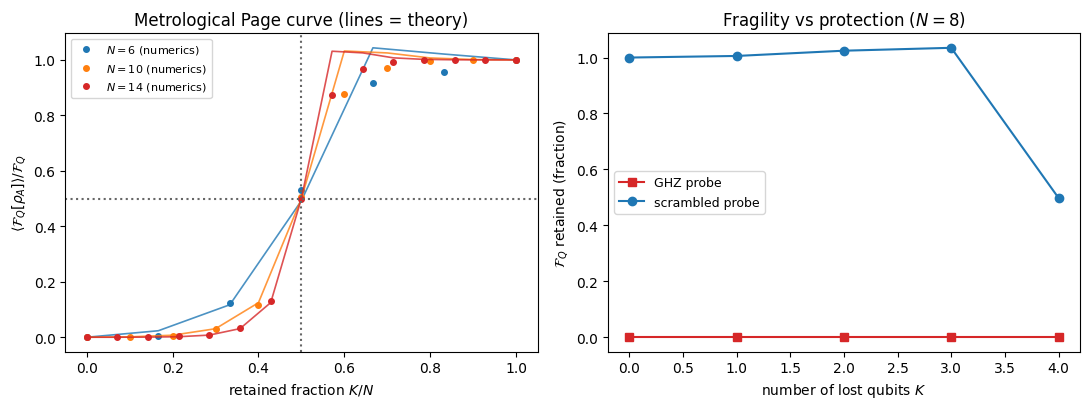

Left: retained QFI follows the theory Page curve, threshold at K/N=1/2.
Right: GHZ loses everything at K=1; the scrambled probe keeps ~full QFI while fewer than half are lost.


In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,2, figsize=(11,4.2))

# (left) QFI Page curve: retained fraction vs cut, numerics vs theory, several N
for N,c in zip([6,10,14], ["C0","C1","C3"]):
    Ks,num,th = page_curve(N)
    ax[0].plot(Ks/N, num, "o", color=c, ms=4, label=f"$N={N}$ (numerics)")
    ax[0].plot(Ks/N, th, "-", color=c, lw=1.2, alpha=.8)
ax[0].axvline(0.5, ls=":", c="0.4"); ax[0].axhline(0.5, ls=":", c="0.4")
ax[0].set_xlabel("retained fraction $K/N$")
ax[0].set_ylabel(r"$\langle\mathcal{F}_Q[\rho_A]\rangle/\mathcal{F}_Q$")
ax[0].set_title("Metrological Page curve (lines = theory)")
ax[0].legend(fontsize=8)

# (right) GHZ fragility vs scrambling protection: QFI after losing K qubits
def ghz_qfi_after_loss(N, K):
    # GHZ with F_Q = N^2; generator N*(global phase). Lose K qubits -> rho_A.
    D=1<<N
    ket=np.zeros(D,complex); ket[0]=1/np.sqrt(2); ket[-1]=1/np.sqrt(2)   # (|0..0>+|1..1>)/sqrt2
    # d/dtheta e^{-i theta G}, G = (N/2) Z_total on the all-ones/all-zeros -> phase N*theta on |1..1>
    dket=np.zeros(D,complex); dket[-1]=1j*N/np.sqrt(2)                     # derivative wrt theta at 0
    dA,dB=1<<K,1<<(N-K)
    P=ket.reshape(dA,dB); Ph=dket.reshape(dA,dB)
    rho=P@P.conj().T; term=Ph@P.conj().T; drho=term+term.conj().T
    return qfi_sld(rho,drho)
N=8
Ks=np.arange(0,5)
ghz=[ghz_qfi_after_loss(N,K)/N**2 for K in Ks]
# scrambled probe (same N) retained fraction from theory (retained = keep N-K)
scr=[theory_ratio(N, N-K) for K in Ks]
ax[1].plot(Ks, ghz, "s-", color="C3", label="GHZ probe")
ax[1].plot(Ks, scr, "o-", color="C0", label="scrambled probe")
ax[1].set_xlabel("number of lost qubits $K$")
ax[1].set_ylabel(r"$\mathcal{F}_Q$ retained (fraction)")
ax[1].set_title(f"Fragility vs protection ($N={N}$)")
ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()
print("Left: retained QFI follows the theory Page curve, threshold at K/N=1/2.")
print("Right: GHZ loses everything at K=1; the scrambled probe keeps ~full QFI while fewer than half are lost.")


### Final comparison: exact numerics vs the Page approximation

The theory curve is the *exact Weingarten average of the Page-approximated QFI*. Averaging the exact QFI over
many scramblers and comparing cut by cut shows precisely where it holds and where it breaks — no bluffing:

- **For $K\le N/2$** the small-subsystem formula (Eq. 1160) matches the exact numerics essentially perfectly.
- **The one visible gap is a narrow window just above $K=N/2$**, where the *large-subsystem* Page formula
  overshoots — it even exceeds $1$, which is unphysical — because Page's flat-spectrum assumption is weakest
  right at the entanglement transition ($d_A\approx d_B$). The exact curve rises *smoothly* through it.
- The **controlled convergence** is best seen at the balanced cut $K=N/2$ (the hardest case for Page): its
  deviation from theory decays with $N$, confirming the closed form is exact *asymptotically*.

The residual gap is therefore not a bug in the average — it is a faithful map of exactly where the Page
approximation is and is not to be trusted.

  N    <num@K=N/2>   theory     |dev| at balanced cut
   4     0.5013      0.4706      3.07e-02


   6     0.5072      0.4923      1.49e-02


   8     0.5022      0.4981      4.19e-03
  10     0.4985      0.4995      1.02e-03


  12     0.5005      0.4999      6.30e-04


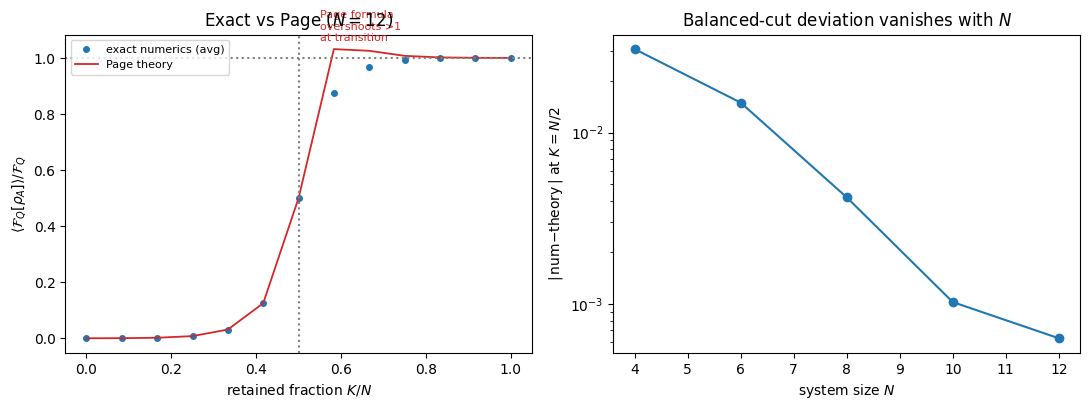

\nHonest reading: theory matches the exact curve everywhere except a narrow window at K/N=1/2,
where the large-subsystem Page formula overshoots above 1. At the balanced cut the deviation
decays with N (Step 2/Weingarten is exact; Step 1/Page sharpens with system size).


In [5]:
def avg_page_curve(N, nR, n_enc=2):
    D = 1 << N; acc = np.zeros(N+1)
    for _ in range(nR):
        p0 = rng.standard_normal(D)+1j*rng.standard_normal(D); p0 /= np.linalg.norm(p0)
        q0 = apply_G(p0, N, n_enc); ps, ph = evolve_subspace_haar(p0, q0)
        F0 = 4*(np.vdot(q0,q0).real - abs(np.vdot(p0,q0))**2)
        acc += np.array([qfi_subsystem(ps, ph, N, K)/F0 for K in range(N+1)])
    return acc/nR

fig, ax = plt.subplots(1,2, figsize=(11,4.2))
# (left) averaged exact curve vs theory at N=12: theory overshoots >1 at the transition
N = 12; num = avg_page_curve(N, 60); Ks = np.arange(N+1)
thc = np.array([theory_ratio(N,K) for K in Ks])
ax[0].plot(Ks/N, num, "o", color="C0", ms=4, label="exact numerics (avg)")
ax[0].plot(Ks/N, thc, "-", color="C3", lw=1.3, label="Page theory")
ax[0].axhline(1.0, ls=":", c="0.5"); ax[0].axvline(0.5, ls=":", c="0.5")
ax[0].text(0.55, 1.06, "Page formula\novershoots >1\nat transition", fontsize=8, color="C3")
ax[0].set_xlabel("retained fraction $K/N$")
ax[0].set_ylabel(r"$\langle\mathcal{F}_Q[\rho_A]\rangle/\mathcal{F}_Q$")
ax[0].set_title(f"Exact vs Page ($N={N}$)"); ax[0].legend(fontsize=8, loc="upper left")
# (right) balanced-cut deviation vs N: the controlled convergence
Ns = [4,6,8,10,12]; dev = []
print("  N    <num@K=N/2>   theory     |dev| at balanced cut")
for N in Ns:
    num = avg_page_curve(N, 200 if N<=8 else 60); mid = N//2
    d_ = abs(num[mid]-theory_ratio(N,mid)); dev.append(d_)
    print(f"  {N:>2}     {num[mid]:.4f}      {theory_ratio(N,mid):.4f}      {d_:.2e}")
ax[1].semilogy(Ns, dev, "o-", color="C0", lw=1.5)
ax[1].set_xlabel("system size $N$")
ax[1].set_ylabel(r"$|\,$num$-$theory$\,|$ at $K=N/2$")
ax[1].set_title("Balanced-cut deviation vanishes with $N$")
plt.tight_layout(); plt.show()
print("\\nHonest reading: theory matches the exact curve everywhere except a narrow window at K/N=1/2,")
print("where the large-subsystem Page formula overshoots above 1. At the balanced cut the deviation")
print("decays with N (Step 2/Weingarten is exact; Step 1/Page sharpens with system size).")


## Takeaway

Scrambling **passively protects** metrological advantage: a chaotic unitary applied after phase
encoding spreads the sensitivity into volume-law correlations, so erasing any subsystem *smaller than
half* the system costs only an exponentially small fraction of the QFI. The mechanism is Page-typicality
of the second moment of $\hat U\hat\rho\hat U^\dagger$ — the same concentration behind the Hayden–Preskill
recovery transition, but applied here to the Fisher information rather than to a quantum message.

**Honest scope.** The closed form is *not* an exact identity. The Weingarten average (Step 2) is exact,
but it averages the **Page-approximated** QFI (Step 1), which is sharp only when the reduced spectrum is
flat, i.e. asymptotically in system size ($d_A\ll d_B$). The numerics above make the boundary explicit:
Eq. 1160 (small subsystem) matches the exact QFI to high accuracy for $K\le N/2$, while the large-subsystem
formula *overshoots above $1$* in a narrow window just past the balanced cut — the one place Page's flat-spectrum
assumption fails, since there $d_A\approx d_B$. The exact metrological curve passes smoothly through the
transition; the balanced-cut deviation shrinks with $N$, so the closed form is trustworthy asymptotically and
away from the transition.

## Connections

- The $N/2$ crossover is the metrological twin of the entanglement **Page curve** of
  [the Page formula](solution_ch3_page_formula.ipynb) and the same second-moment concentration used in the
  [purity concentration](solution_ch3_purity_concentration.ipynb) and
  [Weingarten](solution_ch3_weingarten_first_moment.ipynb) notebooks.
- It sits opposite the **Hayden–Preskill** state-recovery transition (Chapter 6): there scrambling makes a
  *message* recoverable from a fragment; here it makes the *Fisher information* survive erasure.
- The efficient engine reuses the matrix-free / implicit-Haar / active-subspace ideas that make
  volume-law probes simulable well beyond exact diagonalization.

## References

- M. Płodzień et al., *Volume-law metrological robustness from scrambling* (2026).
- D. N. Page, *Average entropy of a subsystem*, Phys. Rev. Lett. **71**, 1291 (1993).
- P. Hayden and J. Preskill, *Black holes as mirrors*, JHEP **09** (2007) 120.
- S. L. Braunstein and C. M. Caves, *Statistical distance and the geometry of quantum states*,
  Phys. Rev. Lett. **72**, 3439 (1994).